In [ ]:
import os
import os.path as osp
import re
from typing import Dict, List, Optional, Tuple
import numpy as np

HEADER_KV_RE = re.compile(r"(\w+)=((?:\".*?\")|(?:[^\s]+))")


def _parse_properties_spec(header_line: str) -> List[Tuple[str, str, int]]:
    """
    Parse the Properties spec from an EXTXYZ header line.
    Returns list of tuples: (name, type_char, count)
    type_char: 'R' float, 'I' int, 'S' string
    """
    match = re.search(r"Properties=\"(.*?)\"", header_line)
    if not match:
        return []
    spec = match.group(1)
    parts = spec.split(':')
    fields: List[Tuple[str, str, int]] = []
    i = 0
    while i < len(parts):
        name = parts[i]
        if i + 2 >= len(parts):
            break
        typ = parts[i + 1]
        try:
            count = int(parts[i + 2])
        except ValueError:
            break
        fields.append((name, typ, count))
        i += 3
    return fields


def _token_to_value(token: str, typ: str):
    if typ == 'R':
        return float(token)
    if typ == 'I':
        return int(token)
    # 'S' or anything else as string
    return token


def read_extxyz_custom(
    path: str,
    *,
    species_map: Optional[Dict[str, str]] = None,
    require_fields: Tuple[str, ...] = ("species", "pos", "charge", "type"),
    scale_length: Optional[float] = None,
) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Read an EXTXYZ trajectory and return arrays:
      - positions: np.ndarray shape (M, N, 3) float64
      - species:   np.ndarray shape (M, N) (unicode strings)
      - charges:   np.ndarray shape (M, N) float64 or None if unavailable
      - types:     np.ndarray shape (M, N) int64 or None if unavailable

    Parameters
    - species_map: optional mapping to remap species labels (e.g., {'Ip': 'X'})
    - require_fields: tuple of field names you expect; if missing, returns None for that field except 'species' and 'pos' which are required
    - scale_length: if provided, multiply positions by this factor (e.g., 10.0 to convert nm->Å)
    """
    positions_frames: List[np.ndarray] = []
    species_frames: List[np.ndarray] = []
    charges_frames: List[np.ndarray] = []
    types_frames: List[np.ndarray] = []
    energies: List = []

    num_particles_expected: Optional[int] = None

    with open(path, 'r') as f:
        frame_index = 0
        while True:
            natoms_line = f.readline()
            if not natoms_line:
                break  # EOF
            natoms_line = natoms_line.strip()
            if not natoms_line:
                # skip empty lines between frames if any
                continue
            try:
                num_atoms = int(natoms_line)
            except ValueError:
                raise ValueError(f"Invalid EXTXYZ at frame {frame_index}: first line is not integer: '{natoms_line}'")

            header_line = f.readline()
            if not header_line:
                raise ValueError(f"Unexpected EOF after natoms at frame {frame_index}")
            header_line = header_line.strip()

            properties = _parse_properties_spec(header_line)
            energies
            # Build a flat list of (field_name, typ) repeated by count, expanding vector fields
            # expanded_fields: List[Tuple[str, str]] = []
            # for name, typ, count in properties:
            #     if count == 1:
            #         expanded_fields.append((name, typ))
            #     else:
            #         # For 'pos' count=3 -> pos[0], pos[1], pos[2]
            #         for k in range(count):
            #             expanded_fields.append((f"{name}[{k}]", typ))

            # Identify indices for fields we care about
            pos_idx = [i for i, (n, t) in enumerate(expanded_fields) if n.startswith('pos[')]
            species_idx = next((i for i, (n, t) in enumerate(expanded_fields) if n == 'species'), None)
            charge_idx = next((i for i, (n, t) in enumerate(expanded_fields) if n == 'charge'), None)
            type_idx = next((i for i, (n, t) in enumerate(expanded_fields) if n == 'type'), None)

            if species_idx is None or len(pos_idx) != 3:
                raise ValueError(
                    f"EXTXYZ missing required fields at frame {frame_index}. Found fields: "
                    f"{[n for n,_ in expanded_fields]}"
                )

            frame_positions = np.empty((num_atoms, 3), dtype=np.float64)
            frame_species = np.empty((num_atoms,), dtype=object)
            frame_charges = np.empty((num_atoms,), dtype=np.float64) if charge_idx is not None else None
            frame_types = np.empty((num_atoms,), dtype=np.int64) if type_idx is not None else None

            for ai in range(num_atoms):
                line = f.readline()
                if not line:
                    raise ValueError(f"Unexpected EOF inside atom block at frame {frame_index}, atom {ai}")
                tokens = line.strip().split()
                if len(tokens) < len(expanded_fields):
                    raise ValueError(
                        f"Atom line too short at frame {frame_index}, atom {ai}: expected >= {len(expanded_fields)} tokens, got {len(tokens)}"
                    )

                # Parse tokens as needed without converting all to Python objects
                # Species
                sp = tokens[species_idx]
                if species_map is not None and sp in species_map:
                    sp = species_map[sp]
                frame_species[ai] = sp
                # Position
                try:
                    px = float(tokens[pos_idx[0]])
                    py = float(tokens[pos_idx[1]])
                    pz = float(tokens[pos_idx[2]])
                except ValueError as e:
                    raise ValueError(f"Invalid float in positions at frame {frame_index}, atom {ai}: {e}")
                frame_positions[ai, 0] = px
                frame_positions[ai, 1] = py
                frame_positions[ai, 2] = pz
                # Charge
                if frame_charges is not None and charge_idx is not None:
                    try:
                        frame_charges[ai] = float(tokens[charge_idx])
                    except ValueError as e:
                        raise ValueError(f"Invalid float in charge at frame {frame_index}, atom {ai}: {e}")
                # Type
                if frame_types is not None and type_idx is not None:
                    try:
                        frame_types[ai] = int(tokens[type_idx])
                    except ValueError as e:
                        raise ValueError(f"Invalid int in type at frame {frame_index}, atom {ai}: {e}")

            if scale_length is not None:
                frame_positions *= float(scale_length)

            if num_particles_expected is None:
                num_particles_expected = num_atoms
            elif num_atoms != num_particles_expected:
                raise ValueError(
                    f"Inconsistent number of atoms across frames: first frame has {num_particles_expected}, current frame has {num_atoms}"
                )

            positions_frames.append(frame_positions)
            species_frames.append(frame_species)
            if frame_charges is not None:
                charges_frames.append(frame_charges)
            if frame_types is not None:
                types_frames.append(frame_types)

            frame_index += 1

    if len(positions_frames) == 0:
        raise ValueError("No frames found in EXTXYZ file")

    positions = np.stack(positions_frames, axis=0)  # (M, N, 3)
    # Convert species to uniform dtype string array of max length
    maxlen = max(max(len(s) for s in fr) for fr in species_frames)
    species = np.empty((len(species_frames), species_frames[0].shape[0]), dtype=f"<U{maxlen}")
    for i, fr in enumerate(species_frames):
        species[i, :] = fr

    charges = None
    types = None

    if charges_frames:
        charges = np.stack(charges_frames, axis=0)  # (M, N)
    if types_frames:
        types = np.stack(types_frames, axis=0)  # (M, N)

    return positions, species, charges, types


# Example usage helper

def load_trajectory_arrays(folder: str, *, species_map: Optional[Dict[str, str]] = None,
                           length_units: str = "nm"):
    path = osp.join(folder, 'trajectory.xyz')
    scale = 10.0 if length_units == 'nm' else None  # convert nm -> Å if requested
    return read_extxyz_custom(path, species_map=species_map, scale_length=scale)



In [ ]:
# Load your trajectory into arrays
folder = "results/ions_dipole_test_1M_steps_20250918_155438"
positions, species, charges, types = load_trajectory_arrays(
    folder,
    species_map={"Ip": "X"},   # remap unknown label(s)
    length_units="nm",          # convert nm -> Å (positions only)
)

print("positions:", positions.shape)
print("species:", species.shape, species.dtype)
print("charges:", None if charges is None else charges.shape)
print("types:", None if types is None else types.shape)

# quick sanity checks
assert positions.ndim == 3 and positions.shape[-1] == 3
assert species.shape[:2] == positions.shape[:2]
if charges is not None:
    assert charges.shape[:2] == positions.shape[:2]
if types is not None:
    assert types.shape[:2] == positions.shape[:2]



In [1]:
import unyt as u
import openmm as mm
from openmm import app
from openmm import unit as u

---

In [36]:
PLANK_CONSTANT = 6.62607015e-34 * u.AVOGADRO_CONSTANT_NA * u.joule * u.second
kT = 120 * u.kelvin * u.BOLTZMANN_CONSTANT_kB * u.AVOGADRO_CONSTANT_NA
# mass = (39.948 * u.atom_mass_units / u.AVOGADRO_CONSTANT_NA).in_units_of(u.kilogram)
mass = 39.948 * u.atom_mass_units

In [37]:
PLANK_CONSTANT**2 / (2 * 3.14 * mass * kT)

Quantity(value=6.361268802813804e-25, unit=second**2*joule/(mole*dalton))

In [38]:
u.sqrt(
    PLANK_CONSTANT**2
    / (2 * 3.14 * mass * kT)
).in_units_of(u.nanometer) ** 3

Quantity(value=1.604410964862414e-05, unit=nanometer**3)

In [16]:
(PLANK_CONSTANT**2 / mass / kT / u.AVOGADRO_CONSTANT_NA).value_in_unit(u.nanometer**2)

TypeError: Unit "second**2*mole**2*joule/kilogram" is not compatible with Unit "nanometer**2".

In [23]:
u.AVOGADRO_CONSTANT_NA

Quantity(value=6.02214076e+23, unit=/mole)

In [62]:
(39.948 * u.atom_mass_units / u.AVOGADRO_CONSTANT_NA).value_in_unit(u.kilogram)

6.633521465546083e-26

In [12]:
u.atomic_mass_unit

Unit({ScaledUnit(factor=1.0, master=gram/mole, name='dalton', symbol='Da'): 1.0})

In [17]:
(39.948 * u.atomic_mass_unit).value_in_unit(u.kilo)

TypeError: Unit "dalton" is not compatible with Unit "<openmm.unit.prefix.SiPrefix object at 0x7f9f8c63e750>".

In [3]:
6.62607015e-34 * u.joule * u.second

Quantity(value=6.62607015e-34, unit=second*joule)

In [25]:
(120 * u.kelvin * u.BOLTZMANN_CONSTANT_kB * u.AVOGADRO_CONSTANT_NA)

Quantity(value=997.7355141783888, unit=joule/mole)

In [10]:
# Load the PDB file
pdb = app.PDBFile('pdb/point.pdb')

In [11]:
system = mm.System()

In [18]:
system.addParticle(5.0)

1

In [14]:
nonbonded = mm.NonbondedForce()

In [19]:
nonbonded.addParticle(0.0, 2.0, 3.0)

1

In [ ]:
system.addForce(nonbonded)

TypeError: System.addForce() takes 2 positional arguments but 3 were given

In [25]:
system.getNumForces()

1

In [22]:
len(pdb.topology.residues())

TypeError: object of type 'generator' has no len()

In [27]:
len(pdb.topology._chains)

1

In [ ]:
# pdb.topology.residues()
for resid, residue in enumerate(pdb.topology.residues()):

0 <Residue 0 (UNK) of chain 0>


In [12]:
list(pdb.getTopology().atoms())

[<Atom 0 (X) of chain 0 residue 0 (UNK)>]

In [4]:
# Use mbuild to create a methane
methane = mbuild.load("C", smiles=True)

In [5]:
# Create an empty mbuild.Box
box = mbuild.Box(lengths=[10.0, 10.0, 10.0])

In [6]:
# Load force field
oplsaa = foyer.forcefields.load_OPLSAA()

In [13]:
force = openmm.CustomExternalForce('100*max(0, r-2)^2; r=sqrt(x*x+y*y+z*z)')

In [16]:
methane.topolo

AttributeError: 'Compound' object has no attribute 'topolo'

In [ ]:
system = openmm.forcefield.createSystem(pdb.topology, nonbondedMethod=CutoffNonPeriodic,
nonbondedCutoff=1*nanometer, constraints=None)

In [10]:
# Use foyer to apply the force field
methane_ff = oplsaa.apply(methane)

/opt/calculation/anaconda3/envs/mc/lib/python3.12/site-packages/foyer/forcefield.py:349: UserWarning: Parameters have not been assigned to all impropers. Total system impropers: 4, Parameterized impropers: 0. Note that if your system contains torsions of Ryckaert-Bellemans functional form, all of these torsions are processed as propers
  warnings.warn(msg)


In [3]:
8.987551792e9 * (1.602176634e-19)**2

2.307077552274694e-28

In [9]:
# Create box and species list
box_list = [box]
species_list = [methane_ff]

NameError: name 'methane_ff' is not defined

In [12]:
mols_to_add = [[100]]

In [8]:
system = mc.System(box_list, species_list, mols_to_add=mols_to_add)
moveset = mc.MoveSet("gcmc", species_list)

NameError: name 'box_list' is not defined

In [14]:
custom_args = {
    "chemical_potentials": [-35.0 * (u.kJ / u.mol)],
    "prop_freq": 100,
}

In [ ]:
mc.run(
    system=system,
    moveset=moveset,
    run_type="equilibration",
    run_length=10000,
    temperature=300.0 * u.K,
    **custom_args,
)

Using the following executables for Cassandra:
Python: /opt/calculation/anaconda3/envs/mc/bin/python
library_setup: /opt/calculation/anaconda3/envs/mc/bin/library_setup.py
Cassandra: /opt/calculation/anaconda3/envs/mc/bin/cassandra.exe
Generating fragment libraries...
Running Cassandra...


In [1]:
import numpy as np

In [9]:

arr = np.array([[1, 2, 3], [4, 5, 6]])

In [10]:
arr.reshape(-1, 3).shape

(2, 3)

In [3]:
A = np.random.rand(10, 3)
b = np.random.rand(3)

In [4]:
A * b

array([[0.10909806, 0.05930931, 0.06923506],
       [0.07570483, 0.03036591, 0.1977214 ],
       [0.3795001 , 0.01584247, 0.03104972],
       [0.00280771, 0.04289635, 0.09326357],
       [0.20954552, 0.00384478, 0.00684573],
       [0.32470425, 0.04550437, 0.19079274],
       [0.34928177, 0.12014609, 0.12719634],
       [0.31079547, 0.01906577, 0.10971425],
       [0.15694612, 0.04798701, 0.09188596],
       [0.19873439, 0.08174198, 0.17131834]])

In [ ]:
Na = 6.02214076

def conv(sigma, b, B, c, d):
    sigma_ =

In [6]:
-0.03382186836982726 - 0.8598403571946756 + 0.14104739588693907 +0.16381667062751226

-0.5887981590500515

In [ ]:
# delta_energy: -3.07651074460583
# delta_kspace_energy: -0.23843067292450904
# delta_self_energy: 0.14104739588693907
# delta_dipole_energy: -0.12095131716320649

-3.07651074460583 - 0.23843067292450904 + 0.14104739588693907 + -0.12095131716320649

-3.415796655969813

In [14]:
# pair_energy: 669.7052428314457
# one_energy: -301.25928222041586
# q_squared_sum: 257.0, len(charges): 257
# kspace_energy: 70.83698691197259
# self_energy: -30.20765061911945
# dipole_energy: -0.48341868790673687
# --------------------------------
# delta_energy: -8.59557480969034
# delta_kspace_energy: -0.6631138922510231
# delta_self_energy: 0.14104739588693907
# delta_dipole_energy: -0.18303283141056634
# --------------------------------
# pair_energy: 660.8697365368865
# one_energy: -301.0193507355468
# q_squared_sum: 256.0, len(charges): 256
# kspace_energy: 70.17387301972157
# self_energy: -30.090111122547004
# dipole_energy: -0.6664515193173001


pair_energy_before = 669.7052428314457
one_energy_before = -301.25928222041586
kspace_energy_before = 70.83698691197259
self_energy_before = -30.20765061911945
dipole_energy_before = -0.48341868790673687

delta_energy = -8.59557480969034
delta_kspace_energy = -0.6631138922510231
delta_self_energy = 0.14104739588693907
delta_dipole_energy = -0.18303283141056634

pair_energy_after = 660.8697365368865
one_energy_after = -301.0193507355468
kspace_energy_after = 70.17387301972157
self_energy_after = -30.090111122547004
dipole_energy_after = -0.6664515193173001

print(f"real_delta_energy: {pair_energy_after + one_energy_after - (pair_energy_before + one_energy_before)}, delta_energy: {delta_energy}")
print(f"real_delta_kspace_energy: {kspace_energy_after - kspace_energy_before}, delta_kspace_energy: {delta_kspace_energy}")
print(f"real_delta_self_energy: {self_energy_after - self_energy_before}, delta_self_energy: {delta_self_energy}")
print(f"real_delta_dipole_energy: {dipole_energy_after - dipole_energy_before}, delta_dipole_energy: {delta_dipole_energy}")

real_delta_energy: -8.595574809690163, delta_energy: -8.59557480969034
real_delta_kspace_energy: -0.6631138922510189, delta_kspace_energy: -0.6631138922510231
real_delta_self_energy: 0.11753949657244434, delta_self_energy: 0.14104739588693907
real_delta_dipole_energy: -0.1830328314105632, delta_dipole_energy: -0.18303283141056634


In [18]:
0.25 / (3.141592653589793**0.5) * 256

36.1081333470564

In [16]:
k

0.14104739588693907

In [1]:
from random import shuffle

In [3]:
arr = list(range(10))
arr

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

In [ ]:
shuffle(arr)

In [5]:
arr

[6, 5, 2, 3, 0, 7, 9, 8, 1, 4]

In [7]:
(1.66054e-3 * 48.80 * 512)**(1/3)

3.4618882245897993

In [5]:
(1.66054e-3 * 41.48 * 256)**(1/3)

2.6028113079906574

---

In [1]:
sigma = 3.048e-8
b = 0.338e-12
B = 2.97e8
c = -48.0e-60
d = -73.0e-76

Na = 6.02214076e23

print("sigma", sigma * 1e7)
print("b'", b * 1e-10 * Na)
print("B", B * 1e-7)
print("c", "{:.3e}".format(c * 1e32 * Na))
print("d", "{:.3e}".format(d * 1e46 * Na))

sigma 0.3048
b' 20.354835768800005
B 29.7
c -2.891e-03
d -4.396e-05


In [2]:
0.5e-8 * 1e7

0.05

In [1]:
d = dict()

In [7]:
import numpy as np

In [1]:
import numpy as np

a = np.array([1, 1, 0, 0, 1, 0])

print(np.argwhere(a == 0).flatten())

[2 3 5]


In [ ]:
import numpy as np
arr = np.array([1, 2, 3, 4, 5, 6])
arr_excluded = arr[arr != 2]
print(arr_excluded)

[1 3 4 5 6]


In [16]:
arr1 = np.array([1, 2, 3, 4, 5, 6])
arr2 = np.array([5, 6, 7, 8, 9, 10])
union = np.union1d(arr1, arr2)
print(union)



[ 1  2  3  4  5  6  7  8  9 10]


In [ ]:
pair_energy: -213.80358711726925, one_energy: 43.4127753790583
delta_energy: 0.3218643541616588
delta_kspace: 0.27785638686232333
delta_dipole: 0.0
pair_energy: -213.4817227631079, one_energy: 42.69981353234766
[force_recompute] translate: dE(delta)=6.00e-01, dE(real)=-1.13e-01, E_cached=-3.69e+02, E_real=-3.69e+02

In [21]:
((-213.4817227631079 + 42.69981353234766) - (-213.80358711726925 + 43.4127753790583))

-0.3910974925493065

In [ ]:
mol_idx: 207
pair_e: -3.2698003607515216, intermol_e: -2.384480833273745, one_e: -34.22513682964369
pair_e: -3.0717905974581394, intermol_e: 0.0, one_e: 27.83706498279912
pair_e: 0.0, intermol_e: 0.0, one_e: 0.0

In [23]:
from scipy.special import lambertw
from scipy.optimize import root_scalar
import numpy as np

In [38]:
W(0.1)

ValueError: f(a) and f(b) must have different signs

In [39]:
lambertw(0.1).real


np.float64(0.09127652716086226)

In [37]:
def W(y):
    # Define the function whose root we want: f(s) = exp(-s^2)/s^2 - eps
    def f(x):
        return x * np.exp(-x) - y
    # Initial guess: for small eps, s is large; try s in [1, 20]
    sol = root_scalar(f, bracket=[1e-10, 5])
    return sol.root

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
distances = np.array([
2.00,
3.00,
4.00,
5.00,
6.00,
7.00,
8.00,
9.00,
10.00,
12.00,
15.00,
18.00,
20.00])

In [3]:
computed_energies = np.array([
-263.203280,
-273.117945,
-275.796950,
-276.791868,
-277.240957,
-277.472114,
-277.602856,
-277.682237,
-277.733172,
-277.791087,
-277.830042,
-277.847303,
-277.853735
])

In [4]:
real_energies = np.array([
-263.203106,
-273.117772,
-275.796779,
-276.791699,
-277.240790,
-277.471949,
-277.602693,
-277.682075,
-277.733010,
-277.790926,
-277.829883,
-277.847144,
-277.853578
])




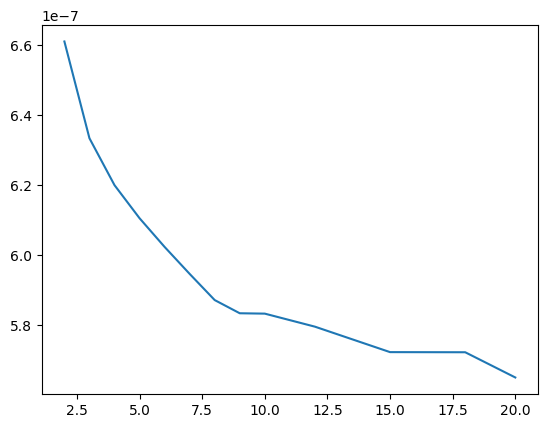

In [5]:
plt.plot(distances, np.abs((computed_energies - real_energies) / real_energies), label="Computed - Real")

In [ ]:
  Distance: 2.00 nm, Computed: -69.467897, Real: -69.467728
  Distance: 3.00 nm, Computed: -46.312177, Real: -46.311819
  Distance: 4.00 nm, Computed: -34.734470, Real: -34.733864
  Distance: 5.00 nm, Computed: -27.788017, Real: -27.787091
  Distance: 6.00 nm, Computed: -23.157239, Real: -23.155909
  Distance: 7.00 nm, Computed: -19.849740, Real: -19.847922
  Distance: 8.00 nm, Computed: -17.369310, Real: -17.366932
  Distance: 9.00 nm, Computed: -15.440272, Real: -15.437273
  Distance: 10.00 nm, Computed: -13.897229, Real: -13.893546
  Distance: 12.00 nm, Computed: -11.583252, Real: -11.577955
  Distance: 15.00 nm, Computed: -9.270658, Real: -9.262364
  Distance: 18.00 nm, Computed: -7.730600, Real: -7.718636
  Distance: 20.00 nm, Computed: -6.961585, Real: -6.946773

---

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def _generate_random_rotation(max_rotation: float) -> np.ndarray:
    # Generate three random numbers for Euler angles
    u1, u2, u3 = np.random.random(3)

    # Max rotation angle in radians
    max_angle = max_rotation * np.pi / 180.0

    # Uniformly sample rotation axis (theta, phi) and angle
    theta = 2 * np.pi * u1  # azimuthal angle [0, 2pi)
    phi = np.arccos(2 * u2 - 1)  # polar angle [0, pi]
    angle = u3 * max_angle  # rotation angle [0, max_angle]

    # Rotation axis (unit vector)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    axis = np.array([x, y, z])

    # Rodrigues' rotation formula
    K = np.array([[0, -z, y], [z, 0, -x], [-y, x, 0]])
    identity = np.eye(3)
    axis_outer = np.outer(axis, axis)
    R = (
        identity * np.cos(angle)
        + (1 - np.cos(angle)) * axis_outer
        + np.sin(angle) * K
    )
    return R

In [24]:
max_rotation = 30

angles = []
for i in range(100000):
    u1, u2 = np.random.random(2)
    theta = 2 * np.pi * u1  # azimuthal angle [0, 2pi)
    phi = np.arccos(2 * u2 - 1)  # polar angle [0, pi]

    # Rotation axis (unit vector)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    vector_init = np.array([x, y, z])

    R = _generate_random_rotation(max_rotation)

    vector_rotated = R @ vector_init

    angle_between = np.rad2deg(np.arccos(np.dot(vector_init, vector_rotated)))
    angles.append(angle_between)

In [37]:
def _rotate_vector_randomly(vector: np.ndarray, max_rotation: float) -> np.ndarray:
    """
    Generate a random 3D rotation matrix using Euler angles.

    Returns:
        3x3 rotation matrix
    """

    vector_init = vector.copy()

    # robust construction of two orthonormal vectors e1,e2 perpendicular to v
    # vector_unit = vector_init / np.linalg.norm(vector_init)
    # # choose auxiliary vector not parallel to v
    # if abs(vector_unit[0]) < 0.9:
    #     tmp = np.array([1.0, 0.0, 0.0])
    # else:
    #     tmp = np.array([0.0, 1.0, 0.0])
    # e1 = np.cross(vector_unit, tmp)
    # e1 /= np.linalg.norm(e1)
    # e2 = np.cross(vector_unit, e1)

    # choose axis uniformly on the circle orthogonal to v
    # phi = 2 * np.pi * np.random.rand()
    # axis = np.cos(phi) * e1 + np.sin(phi) * e2
    # axis = axis / np.linalg.norm(axis)


    vector_unit = vector_init / np.linalg.norm(vector_init)

    # быстрый способ найти ненулевой перпендикуляр
    if abs(vector_unit[2]) < 0.9:
        perp = np.array([-vector_unit[1], vector_unit[0], 0.0])   # гарантированно ⟂ v, если v не || z
    else:
        perp = np.array([0.0, -vector_unit[2], vector_unit[1]])   # если v почти вдоль z, берём другую формулу

    perp /= np.linalg.norm(perp)

    # выбираем случайное направление в плоскости (вращаем вокруг v)
    phi = 2 * np.pi * np.random.rand()
    axis = np.cos(phi) * perp + np.sin(phi) * np.cross(vector_unit, perp)
    axis = axis / np.linalg.norm(axis)

    # Generate three random numbers for Euler angles

    # Max rotation angle in radians
    max_angle = max_rotation * np.pi / 180.0

    # Uniformly sample rotation axis (theta, phi) and angle
    angle = np.random.random() * max_angle  # rotation angle [0, max_angle]

    # Rotation axis (unit vector)

    # Rodrigues' rotation formula
    x, y, z = axis
    K = np.array([[0, -z, y], [z, 0, -x], [-y, x, 0]])
    identity = np.eye(3)
    axis_outer = np.outer(axis, axis)
    R = (
        identity * np.cos(angle)
        + (1 - np.cos(angle)) * axis_outer
        + np.sin(angle) * K
    )

    vector_rotated = R @ vector_init

    return vector_rotated

In [38]:
max_rotation = 30

angles = []
for i in range(100000):
    u1, u2 = np.random.random(2)
    theta = 2 * np.pi * u1  # azimuthal angle [0, 2pi)
    phi = np.arccos(2 * u2 - 1)  # polar angle [0, pi]

    # Rotation axis (unit vector)
    x = np.sin(phi) * np.cos(theta)
    y = np.sin(phi) * np.sin(theta)
    z = np.cos(phi)
    vector_init = np.array([x, y, z])

    vector_rotated = _rotate_vector_randomly(vector_init, max_rotation)

    angle_between = np.rad2deg(np.arccos(np.dot(vector_init, vector_rotated)))
    angles.append(angle_between)

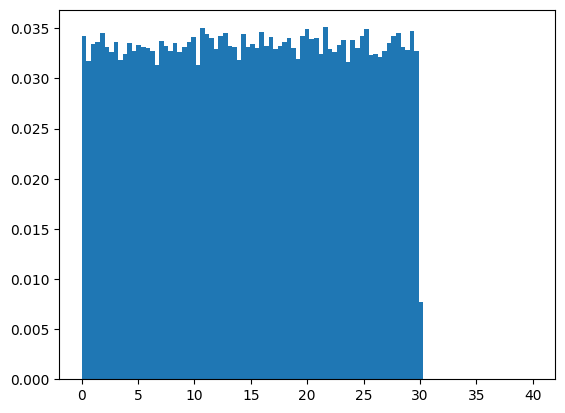

In [39]:
plt.hist(angles, bins=np.linspace(0, max_rotation+10, 100), density=True)

plt.show()

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
N = 32
box = np.array([10, 10, 10])
charges = np.ones(N, dtype=int)
charges[np.random.choice(range(N), size=N // 2, replace=False)] = -1
pos = np.random.rand(N, 3) * box

In [4]:
E = 0

n_images = 4
for i in range(N):
    for j in range(N):
        for nx in range(-n_images, n_images + 1):
            for ny in range(-n_images, n_images + 1):
                for nz in range(-n_images, n_images + 1):
                    if nx==0 and ny==0 and nz==0 and i==j:
                        continue

                    r = pos[j, :] + np.array([nx, ny, nz]) * box - pos[i, :]
                    E += charges[i] * charges[j] / (np.linalg.norm(r))
E *= 0.5
print(E)

0.6899349567176898


In [ ]:
    # 2. Взаимодействие частиц с их собственными образами
    # for i in range(N):
    #     for nx in range(-n_image, n_image + 1):
    #         for ny in range(-n_image, n_image + 1):
    #             for nz in range(-n_image, n_image + 1):
    #                 # Пропускаем основной образ (частица с самой собой)
    #                 if nx == 0 and ny == 0 and nz == 0:
    #                     continue
    #                 r = np.array([nx, ny, nz]) * box  # расстояние до собственного образа
    #                 E += 0.5 * charges[i] * charges[i] / np.linalg.norm(r)

In [2]:
E_arr = []
E_arr_N2 = []
n_images = list(range(0, 5))

N = 32
box = np.array([10, 10, 10])
charges = np.ones(N, dtype=int)
charges[np.random.choice(range(N), size=N // 2, replace=False)] = -1
pos = np.random.rand(N, 3) * box

for n_image in n_images:
    print('processing n_image:', n_image)
    E = 0
    for i in range(N):
        for j in range(N):
            for nx in range(-n_image, n_image + 1):
                for ny in range(-n_image, n_image + 1):
                    for nz in range(-n_image, n_image + 1):
                        if nx==0 and ny==0 and nz==0 and i==j:
                            continue

                        r = pos[j, :] + np.array([nx, ny, nz]) * box - pos[i, :]
                        E += charges[i] * charges[j] / (np.linalg.norm(r))
    E *= 0.5
    E_arr_N2.append(E)

    # E = 0
    # # 1. Взаимодействие между разными частицами (i != j)
    # for i in range(N):
    #     for j in range(i, N):
    #         r = pos[j, :] - pos[i, :]
    #         # r -= box * np.round(r / box) # Wrap around the box
    #         for nx in range(-n_image, n_image + 1):
    #             for ny in range(-n_image, n_image + 1):
    #                 for nz in range(-n_image, n_image + 1):
    #                     r_image = r + np.array([nx, ny, nz]) * box
    #                     # if nx != 0 and ny != 0 and nz != 0:
    #                     #     r_image -= (np.abs(np.array([nx, ny, nz]))) * box * np.round(r_image / (np.abs(np.array([nx, ny, nz]))) / box) # Wrap around the big box

    #                     if i == j:
    #                         if nx == 0 and ny == 0 and nz == 0:
    #                             continue
    #                         E += 0.5 * charges[i] * charges[j] / np.linalg.norm(r_image)
    #                     else:
    #                         E += charges[i] * charges[j] / np.linalg.norm(r_image)
    E = 0
    for i in range(N):
        indices = np.arange(i, N)
        r_ij = pos[indices, :] - pos[i, :]
        for nx in range(-n_image, n_image + 1):
            for ny in range(-n_image, n_image + 1):
                for nz in range(-n_image, n_image + 1):
                    r_image = r_ij + np.array([nx, ny, nz]) * box
                    r_image_norm = np.linalg.norm(r_image, axis=1)
                    mask = r_image_norm > 1e-9
                    # if nx != 0 and ny != 0 and nz != 0:
                    #     r_image -= (np.abs(np.array([nx, ny, nz]))) * box * np.round(r_image / (np.abs(np.array([nx, ny, nz]))) / box) # Wrap around the big box

                    E_ij = charges[i] * charges[indices][mask] / np.linalg.norm(r_image[mask], axis=1)
                    if mask[0]:
                        E_ij[0] *= 0.5

                    E += np.sum(E_ij)
    E_arr.append(E)


processing n_image: 0
processing n_image: 1
processing n_image: 2
processing n_image: 3
processing n_image: 4


In [3]:
print('n_images:', [float(n_image) for n_image in n_images])
print('E_arr_N2:', [float(E_arr_N2[i]) for i in range(len(n_images))])
print('E_arr:', [float(E_arr[i]) for i in range(len(n_images))])


n_images: [0.0, 1.0, 2.0, 3.0, 4.0]
E_arr_N2: [-7.047304804248781, -5.225261559398024, -5.221221106696244, -5.220241727728712, -5.219824285126305]
E_arr: [-7.047304804248791, -5.2252615593979925, -5.221221106696452, -5.2202417277285, -5.219824285125019]


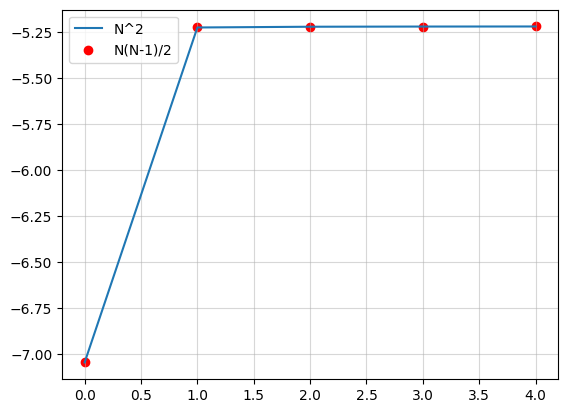

In [4]:
plt.grid(alpha=0.5)
plt.plot(n_images, E_arr_N2, label='N^2')
plt.scatter(n_images, E_arr, label='N(N-1)/2', color='red')
plt.legend()
plt.show()

---

In [1]:
import ase
from ase.io import read
import os
import os.path as osp
import numpy as np

In [2]:
folder = "results/ions_dipole_test_1M_steps_20250918_155438"
# traj = read(osp.join(folder, 'trajectory.xyz'), format='extxyz')

In [3]:
with open(osp.join(folder, 'trajectory.xyz'), 'r') as f:
    count = 0
    for line in f:
        print(line.strip('\n'))
        count += 1
        if count > 1500:
            break



1324
Lattice="20.00 0.00 0.00 0.00 20.00 0.00 0.00 0.00 5.00" pbc="T T F" Properties="species:S:1:pos:R:3:charge:R:1:mass:R:1:type:I:1" energy=-2297.509063 temperature=298.000000 pressure=nan step=100 time=1.485554 units_energy="kJ/mol" units_length="nm" units_temperature="K" units_pressure="kJ/mol/nm^3" ensemble="NVT"
Na    14.085507     3.828906     3.979719     1.000000    39.098300 0
Na    11.978032    19.038891     1.021864     1.000000    39.098300 0
Na     7.651271    14.832281     3.631194     1.000000    39.098300 0
Na     1.254382    14.866346     4.063390     1.000000    39.098300 0
Na    17.305639     7.707952     1.167063     1.000000    39.098300 0
Na    13.261421     5.642369     2.453156     1.000000    39.098300 0
Na     1.719454     8.192382     4.332449     1.000000    39.098300 0
Na     4.765756    11.874767     2.697508     1.000000    39.098300 0
Na    13.102859     7.197742     1.718684     1.000000    39.098300 0
Na     3.272113    12.785629     0.933541     1.0

In [4]:
import shlex

def parse_key_value_string(s):
    # Разбиваем строку с учётом кавычек
    parts = shlex.split(s)
    result = {}

    for part in parts:
        if '=' in part:
            key, value = part.split('=', 1)
            value = value.strip('"')
            # Пробуем привести к числу, если возможно
            if value.lower() == 'nan':
                result[key] = float('nan')
            elif value.replace('.', '', 1).isdigit():
                result[key] = float(value)
            else:
                result[key] = value
    return result


s = 'Lattice="20.00 0.00 0.00 0.00 20.00 0.00 0.00 0.00 5.00" pbc="T T F" Properties="species:S:1:pos:R:3:charge:R:1:mass:R:1:type:I:1" energy=-2319.579455 temperature=298.000000 pressure=nan step=200 time=2.106655 units_energy="kJ/mol" units_length="nm" units_temperature="K" units_pressure="kJ/mol/nm^3" ensemble="NVT"'

parsed = parse_key_value_string(s)
for k, v in parsed.items():
    print(f"{k} = {v}")


Lattice = 20.00 0.00 0.00 0.00 20.00 0.00 0.00 0.00 5.00
pbc = T T F
Properties = species:S:1:pos:R:3:charge:R:1:mass:R:1:type:I:1
energy = -2319.579455
temperature = 298.0
pressure = nan
step = 200.0
time = 2.106655
units_energy = kJ/mol
units_length = nm
units_temperature = K
units_pressure = kJ/mol/nm^3
ensemble = NVT


---

In [3]:
import os
import os.path as osp
import numpy as np
import matplotlib.pyplot as plt

In [10]:
folder = "results/ions_dipole_verification"

In [5]:
import os.path as osp
from typing import List, Optional, Tuple
import numpy as np

import shlex

def parse_key_value_string(s):
    # Разбиваем строку с учётом кавычек
    parts = shlex.split(s)
    result = {}

    for part in parts:
        if '=' in part:
            key, value = part.split('=', 1)
            value = value.strip('"')
            # Пробуем привести к числу, если возможно
            if value.lower() == 'nan':
                result[key] = float('nan')
            elif value.replace('.', '', 1).isdigit():
                result[key] = float(value)
            else:
                result[key] = value
    return result


def read_xyz(
    path: str,
) -> Tuple[np.ndarray, np.ndarray, Optional[np.ndarray], Optional[np.ndarray]]:
    """
    Read an EXTXYZ trajectory and return arrays:
      - positions: np.ndarray shape (M, N, 3) float64
      - species:   np.ndarray shape (M, N) (unicode strings)
      - charges:   np.ndarray shape (M, N) float64 or None if unavailable
      - types:     np.ndarray shape (M, N) int64 or None if unavailable

    Parameters
    - species_map: optional mapping to remap species labels (e.g., {'Ip': 'X'})
    - require_fields: tuple of field names you expect; if missing, returns None for that field except 'species' and 'pos' which are required
    - scale_length: if provided, multiply positions by this factor (e.g., 10.0 to convert nm->Å)
    """
    positions_frames: List[np.ndarray] = []
    species_frames: List[np.ndarray] = []
    charges_frames: List[np.ndarray] = []
    masses_frames: List[np.ndarray] = []
    types_frames: List[np.ndarray] = []
    boxes: List[np.ndarray] = []
    energies: List = []

    num_particles_expected: Optional[int] = None

    with open(path, 'r') as f:
        frame_index = 0
        while True:
            natoms_line = f.readline()
            if not natoms_line:
                break  # EOF
            natoms_line = natoms_line.strip()
            if not natoms_line:
                # skip empty lines between frames if any
                continue
            try:
                num_atoms = int(natoms_line)
            except ValueError:
                raise ValueError(f"Invalid XYZ at frame {frame_index}: first line is not integer: '{natoms_line}'")

            header_line = f.readline()
            if not header_line:
                raise ValueError(f"Unexpected EOF after natoms at frame {frame_index}")
            header_line = header_line.strip()

            properties = parse_key_value_string(header_line)
            boxes.append(np.array(properties.get('Lattice', None).split(), dtype=np.float64))
            energies.append(float(properties.get('energy', None)))

            frame_positions = np.empty((num_atoms, 3), dtype=np.float64)
            frame_species = np.empty((num_atoms,), dtype=object)
            frame_charges = np.empty((num_atoms,), dtype=np.float64)
            frame_masses = np.empty((num_atoms,), dtype=np.float64)
            frame_types = np.empty((num_atoms,), dtype=np.int64)

            for ai in range(num_atoms):
                line = f.readline()
                if not line:
                    raise ValueError(f"Unexpected EOF inside atom block at frame {frame_index}, atom {ai}")
                tokens = line.strip().split()
                if len(tokens) < 7:
                    raise ValueError(
                        f"Atom line too short at frame {frame_index}, atom {ai}: expected >= {len(expanded_fields)} tokens, got {len(tokens)}"
                    )

                # Species
                frame_species[ai] = tokens[0]
                # Position
                frame_positions[ai, 0] = float(tokens[1])
                frame_positions[ai, 1] = float(tokens[2])
                frame_positions[ai, 2] = float(tokens[3])
                # Charge
                frame_charges[ai] = float(tokens[4])
                # Mass
                frame_masses[ai] = float(tokens[5])
                # Type
                frame_types[ai] = int(tokens[6])

            positions_frames.append(frame_positions)
            species_frames.append(frame_species)
            charges_frames.append(frame_charges)
            masses_frames.append(frame_masses)
            types_frames.append(frame_types)

            frame_index += 1

    positions = np.stack(positions_frames, axis=0)  # (M, N, 3)
    # Convert species to uniform dtype string array of max length
    maxlen = max(max(len(s) for s in fr) for fr in species_frames)
    species = np.empty((len(species_frames), species_frames[0].shape[0]), dtype=f"<U{maxlen}")
    for i, fr in enumerate(species_frames):
        species[i, :] = fr

    charges = np.stack(charges_frames, axis=0)  # (M, N)
    masses = np.stack(masses_frames, axis=0)  # (M, N)
    types = np.stack(types_frames, axis=0)  # (M, N)

    boxes = np.stack(boxes, axis=0)  # (M, 9)
    energies = np.stack(energies, axis=0)  # (M,)

    return positions, species, charges, masses, types, boxes, energies

In [6]:
positions, species, charges, masses, types, boxes, energies = read_xyz(osp.join(folder, 'trajectory.xyz'))

In [7]:
def calculate_coulomb_energy(positions: np.ndarray, charges: np.ndarray, box: np.ndarray, n_image: int = 0, dielectric: float = 1.0, units: float = 1):
    N = positions.shape[0]
    box_remaped = np.array([box[0], box[4], box[8]])
    E = 0
    # 1. Взаимодействие между разными частицами (i != j)
    for i in range(N):
        # for j in range(i, N):
        indices = np.arange(i, N)
        r_ij = pos[indices, :] - pos[i, :]
        for nx in range(-n_image, n_image + 1):
            for ny in range(-n_image, n_image + 1):
                # for nz in range(-n_image, n_image + 1):
                nz = 0
                r_image = r_ij + np.array([nx, ny, nz]) * box_remaped
                r_image_norm = np.linalg.norm(r_image, axis=1)
                mask = r_image_norm > 1e-9

                E_ij = charges[i] * charges[indices][mask] / r_image_norm[mask]
                if mask[0]:
                    E_ij[0] *= 0.5

                E += np.sum(E_ij)
    return units * E / dielectric

In [8]:
i = -1
pos = positions[i]
charge = charges[i]
box = boxes[i]

E_real = energies[i]
print("E_real", E_real)

# Get electric field vector
voltage = 0.3 * 96.4
E = voltage / box[8]
energy_electric = np.sum(-charge * E * pos[:, 2])
print("energy_electric", energy_electric)

n_images = list(range(0, 10))
coulomb_energies = []
for n_im in n_images:
    coulomb_energies.append(calculate_coulomb_energy(pos, charge, box, n_image=n_im, dielectric=78.0, units=138.935456))
    print(f"E_coulomb {n_im}", coulomb_energies[-1])

print("Total energy", coulomb_energies[-1] + energy_electric)
# print("E_coulomb - E_real", E_coulomb - E_real)

E_real -3441.409496
energy_electric -1369.5252201420003
E_coulomb 0 -1990.2637219277478
E_coulomb 1 -1913.0898590782278
E_coulomb 2 -1902.693665833311
E_coulomb 3 -1898.497200043887
E_coulomb 4 -1896.2086277174053
E_coulomb 5 -1894.7641364915035
E_coulomb 6 -1893.7684429631029
E_coulomb 7 -1893.0401557657187
E_coulomb 8 -1892.484158135018
E_coulomb 9 -1892.0457115879783
Total energy -3261.570931729979


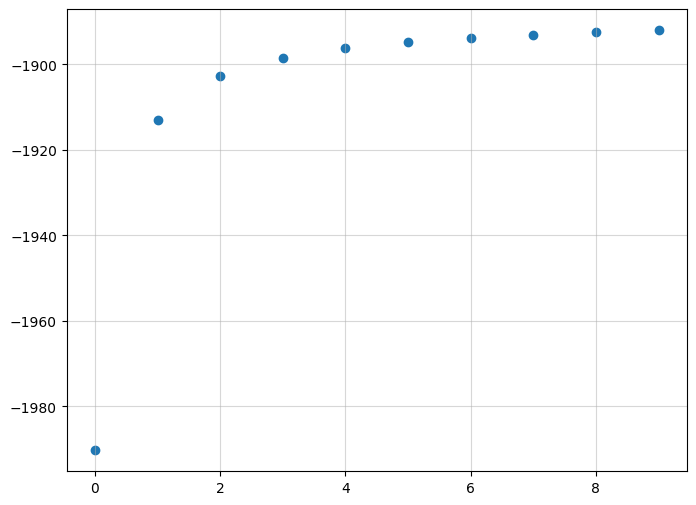

In [9]:
plt.figure(figsize=(8, 6))
plt.grid(alpha=0.5)

plt.scatter(n_images, coulomb_energies)

plt.show()

---

In [11]:
from src.system import System
from src.topology import Topology
from src.utils import load_config, create_units, create_system, create_topology, setup_initial_configuration

In [12]:
cfg = load_config(osp.join(folder, "config_backup.yaml"))

# Create system components
units = create_units(cfg)
system = create_system(cfg, units)
topology = create_topology(cfg, units)


====== TOPOLOGY CONFIGURATION SUMMARY ======

Registered Types:
  0: Na (mass=39.0983, charge=1.0)
  1: Cl (mass=35.453, charge=-1.0)
  2: Ip (mass=18.01528, charge=0.75)
  3: Im (mass=18.01528, charge=-0.75)
  4: G (mass=0.0, charge=0.0)

Pair Interactions:
  Na(0) - Na(0): HardSphere, EwaldReal
  Cl(1) - Cl(1): HardSphere, EwaldReal
  Na(0) - Cl(1): HardSphere, EwaldReal
  Na(0) - Ip(2): HardSphere, EwaldReal
  Na(0) - Im(3): HardSphere, EwaldReal
  Cl(1) - Ip(2): HardSphere, EwaldReal
  Cl(1) - Im(3): HardSphere, EwaldReal
  Na(0) - G(4): HardSphere
  Cl(1) - G(4): HardSphere
  Ip(2) - Ip(2): HardSphere, EwaldReal
  Im(3) - Im(3): HardSphere, EwaldReal
  Ip(2) - Im(3): HardSphere, EwaldReal
  Ip(2) - G(4): HardSphere
  Im(3) - G(4): HardSphere
  G(4) - G(4): HardSphere

One-Body Forces:
  Na(0): HardWall, HardWall
  Cl(1): HardWall, HardWall
  Ip(2): HardWall, HardWall
  Im(3): HardWall, HardWall
  G(4): HardWall, HardWall



In [13]:
setup_initial_configuration(
    system,
    cfg.get("types", []),
    topology,
    cfg=cfg,
)

min_dist: 0.404010250633011


In [14]:
system.positions

array([[19.48560003,  8.9261139 ,  0.93396305],
       [ 3.42922413, 15.82266034,  1.5647342 ],
       [13.91428402,  0.25236972,  4.45350631],
       ...,
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        ]], shape=(2048, 3))

In [15]:
# eps = 1e-8
# real_cut = np.min(system.box[:3]) / 2.0
# alpha = np.sqrt(-np.log(eps)) / real_cut
# n_c = np.ceil(2 * np.sqrt(alpha * (-np.log(eps))) * np.min(system.box[:3]) / (2 * np.pi))

# system.ewald_handler.real_cut = real_cut
# system.ewald_handler.alpha = alpha
# system.ewald_handler.n_c = n_c

In [16]:
for i,p in enumerate(pos):
    system.positions[i] = p

In [17]:
system.positions

array([[19.211093, 18.575544,  4.846358],
       [ 9.550006,  8.404571,  4.574681],
       [13.36258 ,  6.830557,  4.609679],
       ...,
       [ 0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ],
       [ 0.      ,  0.      ,  0.      ]], shape=(2048, 3))

In [18]:
if system.ewald_handler:
    system.ewald_handler.initialize_k_vectors(system.box)
    system.ewald_handler.update_structure_factors(
        system.positions[: system.N_atoms],
        system.charges[: system.N_atoms],
    )
    system.ewald_handler.update_dipole_moment(
        system.positions[: system.N_atoms],
        system.charges[: system.N_atoms],
    )

In [19]:
topology.compute_energy_virial(system)

(np.float64(-2071.8842284771026), np.float64(-2098.2232876171197))

In [38]:
eps_list = [1, 1e-1, 1e-2, 1e-3, 1e-4, 1e-5, 1e-6]
energy_list = []
for eps in eps_list:
    real_cut = np.min(system.box[:3]) / 2.0
    alpha = np.sqrt(-np.log(eps)) / real_cut
    n_c = np.ceil(2 * np.sqrt(alpha * (-np.log(eps))) * np.min(system.box[:3]) / (2 * np.pi))
    print(f"eps: {eps}, real_cut: {real_cut}, alpha: {alpha}, n_c: {n_c}")

    system.ewald_handler.real_cut = real_cut
    system.ewald_handler.alpha = alpha
    system.ewald_handler.n_c = n_c

    system.ewald_handler.initialize_k_vectors(system.box)
    system.ewald_handler.update_structure_factors(
        system.positions[: system.N_atoms],
        system.charges[: system.N_atoms],
    )
    system.ewald_handler.update_dipole_moment(
        system.positions[: system.N_atoms],
        system.charges[: system.N_atoms],
    )

    en, _ = topology.compute_energy_virial(system)
    energy_list.append(en)


eps: 1, real_cut: 2.5, alpha: -0.0, n_c: 0.0
eps: 0.1, real_cut: 2.5, alpha: 0.6069708517540585, n_c: 2.0
eps: 0.01, real_cut: 2.5, alpha: 0.8583864105157388, n_c: 4.0
eps: 0.001, real_cut: 2.5, alpha: 1.0513043539513864, n_c: 5.0
eps: 0.0001, real_cut: 2.5, alpha: 1.213941703508117, n_c: 6.0
eps: 1e-05, real_cut: 2.5, alpha: 1.3572280848830223, n_c: 7.0
eps: 1e-06, real_cut: 2.5, alpha: 1.4867688755399353, n_c: 8.0


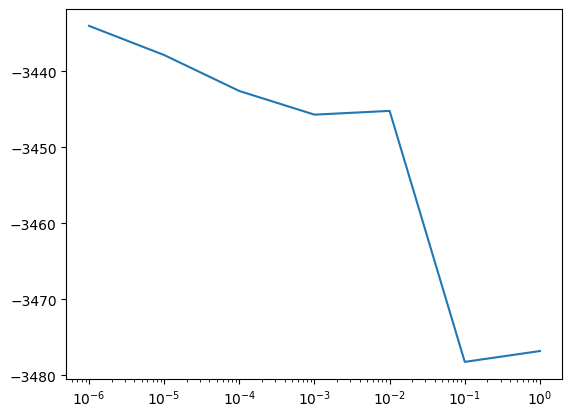

In [40]:
plt.plot(eps_list, energy_list)
plt.xscale('log')
plt.show()